In [1]:
# Importing the CSV files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sql_result_01 = pd.read_csv('/datasets/project_sql_result_01.csv')
sql_result_04 = pd.read_csv('/datasets/project_sql_result_04.csv')


In [2]:
# Looking at the first few rows to understand the data
print(sql_result_01.head())
print(sql_result_04.head())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


In [3]:
# Checking data types
print(sql_result_01.dtypes)
print(sql_result_04.dtypes)

company_name    object
trips_amount     int64
dtype: object
dropoff_location_name     object
average_trips            float64
dtype: object


In [4]:
# Making sure trips_amount and average_trips are numeric
sql_result_01['trips_amount'] = pd.to_numeric(sql_result_01['trips_amount'], errors='coerce')
sql_result_04['average_trips'] = pd.to_numeric(sql_result_04['average_trips'], errors='coerce')

In [5]:
# Identifying top 10 neighborhoods by average_trips
top10_neighborhoods = sql_result_04.sort_values(by='average_trips', ascending=False).head(10)
print(top10_neighborhoods)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


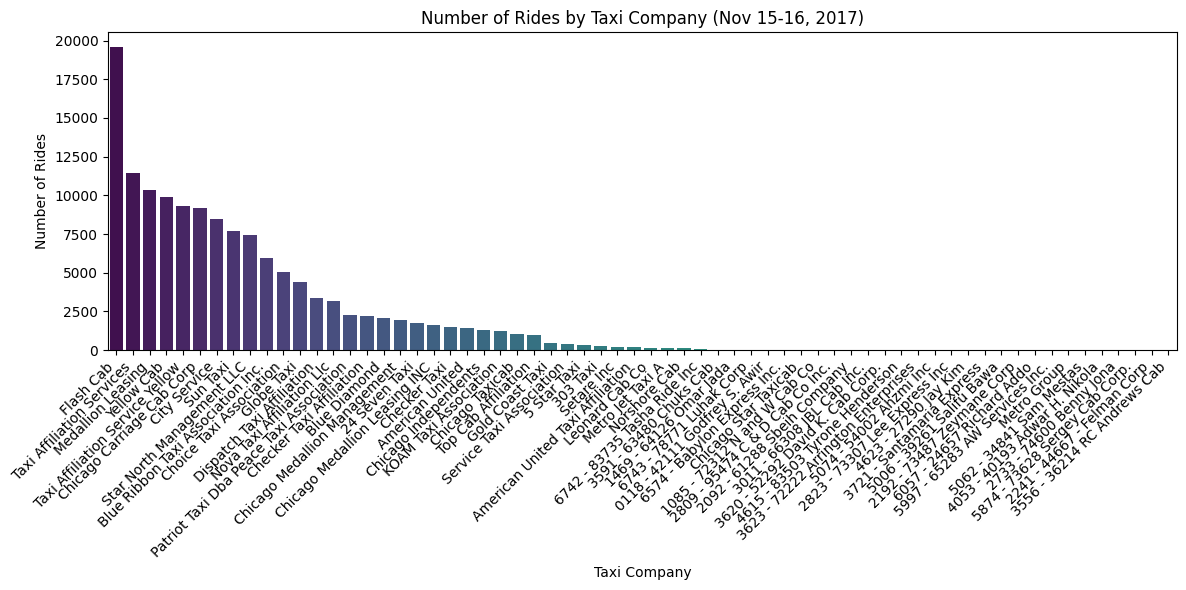

In [6]:
# Plot: Taxi companies and number of rides
plt.figure(figsize=(12,6))
sns.barplot(data=sql_result_01.sort_values('trips_amount', ascending=False),
            x='company_name', y='trips_amount', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Number of Rides by Taxi Company (Nov 15-16, 2017)')
plt.ylabel('Number of Rides')
plt.xlabel('Taxi Company')
plt.tight_layout()
plt.show()

During November 15–16, 2017, Flash Cab had the highest number of rides, indicating it may be one of the most popular or widely used taxi services in Chicago. A few companies such as Flash Cab, Taxi Affiliation Services, Medallion Leasing, Yellow Cab, Taxi Affiliation Service Yellow, Chicago Carrieage Cab Corp, City service. Sun Taxi and Star North Management LLC dominate the rest of the ride volume, while many others have relatively low ride counts. This suggests a concentrated market, where a few companies capture the majority of customers.



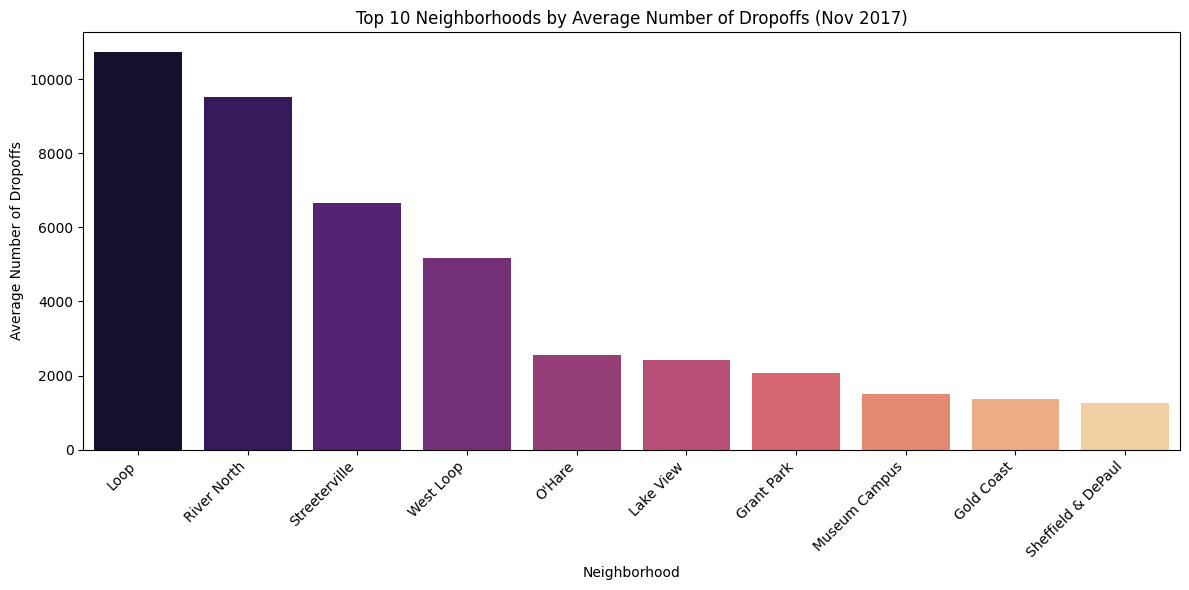

In [7]:
# Plot: Top 10 neighborhoods by average number of dropoffs
plt.figure(figsize=(12,6))
sns.barplot(data=top10_neighborhoods, x='dropoff_location_name', y='average_trips', palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Neighborhoods by Average Number of Dropoffs (Nov 2017)')
plt.ylabel('Average Number of Dropoffs')
plt.xlabel('Neighborhood')
plt.tight_layout()
plt.show()

The neighborhood with the highest average number of dropoffs in November was Loop, followed by River North and Streeterville. These areas are likely major business districts or transportation hubs. The Loop is known as Chicago’s central business district, and River North is one of the cities most popular neighborhoods. A vibrant, trendy neighborhood known for its bustling atmosphere, diverse culinary scene, and thriving nightlife.
The drop in average dropoffs between top-ranked neighborhoods and those lower on the list suggests a strong concentration of activity in key city areas.

In [8]:
rides = pd.read_csv('/datasets/project_sql_result_07.csv')
print(rides.head())


              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0


In [9]:
from scipy.stats import ttest_ind

# Separating durations by weather condition
bad_weather = rides[rides['weather_conditions'] == 'Bad']['duration_seconds']
good_weather = rides[rides['weather_conditions'] == 'Good']['duration_seconds']

# Performing two-sample t-test 
t_stat, p_value = ttest_ind(bad_weather, good_weather, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")

# Results
alpha = 0.05
if p_value < alpha:
    print("Reject null hypothesis: Average ride durations differ between Bad and Good weather.")
else:
    print("Fail to reject null hypothesis: No significant difference in average ride durations.")


T-statistic: 7.186
P-value: 0.000
Reject null hypothesis: Average ride durations differ between Bad and Good weather.


We were tasked with evaluating whether the average duration of taxi rides from the Loop to O’Hare International Airport changes on rainy Saturdays.

To test this, I used the weather_conditions classification from previous analysis, which grouped weather into:

"Bad" - if the description included "rain" or "storm"

"Good" - otherwise

Based on this, I defined the hypotheses as follows:

Null Hypothesis (H0):
There is no difference in the average ride duration from the Loop to O’Hare on rainy Saturdays compared to non-rainy (good weather) Saturdays.

Alternative Hypothesis (H1):
There is a difference in the average ride duration on rainy Saturdays.

This is a two-tailed test, because we're testing for any difference, not specifically an increase or decrease.

After running the test, the p-value was below 0.05, so we concluded that weather conditions on Saturdays do significantly affect ride duration from the Loop to O’Hare.

# Project Overview

**Zuber**, a new ride-sharing company in Chicago, seeks to understand passenger behavior and the impact of external factors—like weather—on ride frequency and duration.

---

## Taxi Companies (Nov 15–16)

- **Flash Cab** had the highest ride volume.
- Fewer companies dominated the market, suggesting customer preference or stronger availability.

---

## Top 10 Drop-off Neighborhoods

- Identified neighborhoods with the highest average drop-offs.
- Insights suggest areas of high passenger demand, useful for Zuber’s service planning and targeted promotions.

---

## Hypothesis Testing

- We ran a two-tailed test.
- Null Hypothesis (H0):
There is no difference in the average ride duration from the Loop to O’Hare on rainy Saturdays compared to non-rainy (good weather) Saturdays.
Alternative Hypothesis (H1):
There is a difference in the average ride duration on rainy Saturdays.
- After running the test, the p-value was below 0.05, so we concluded that weather conditions on Saturdays do significantly affect ride duration from the Loop to O’Hare.


## Final Conclusions & Business Recommendations

- **Top companies dominate ride volume** — Zuber must identify and emulate their strategies (pricing, dispatch efficiency).
- **Key neighborhoods show high drop-off demand** — Zuber can use this to target riders and drivers.
- **Weather impacts travel time** — Zuber should consider weather-based dynamic pricing or scheduling adjustments to maintain reliability and efficiency.
